# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1 :
- Alumno 2 :

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [1]:
# TO-DO: completar con la URL de tu fork.
# Repo privado: https://<TOKEN>@github.com/<usuario>/tuia-dog-recognition-app.git
REPO_URL = "https://github.com/<usuario>/tuia-dog-recognition-app.git"

!git clone $REPO_URL proyecto
%cd proyecto

[WinError 2] The system cannot find the file specified: 'proyecto'
c:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app


The system cannot find the file specified.


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [2]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [3]:
import os
import sys
from pathlib import Path

os.environ["USE_PGVECTOR"] = "false"
# Ajusta aca cualquier otra variable (IMAGE_SIZE, EMBEDDING_DIM, paths, etc.)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

dataset_path: data\dataset
GPU disponible: False


## 4. Descargar el dataset

In [4]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Ya existe, se omite: C:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset\dogs.csv
Ya existe, se omite: C:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset\test
Ya existe, se omite: C:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset\train
Ya existe, se omite: C:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset\valid
Dataset disponible en C:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset


'ls' is not recognized as an internal or external command,
operable program or batch file.


## 5. Analisis del dataset

TO-DO:
- Analizar la distribucion de clases y documentar la cantidad de imagenes por raza.
- Definir los conjuntos de entrenamiento, validacion y prueba.
- Construir un conjunto independiente para evaluacion (ej: imagenes descargadas de internet).
- Filtrar imagenes de baja calidad (documentar el criterio).

C:\Users\maxir\AppData\Local\Temp\ipykernel_10784\2293114973.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_classes.keys())[:20], y=list(sorted_classes.values())[:20], palette="viridis")


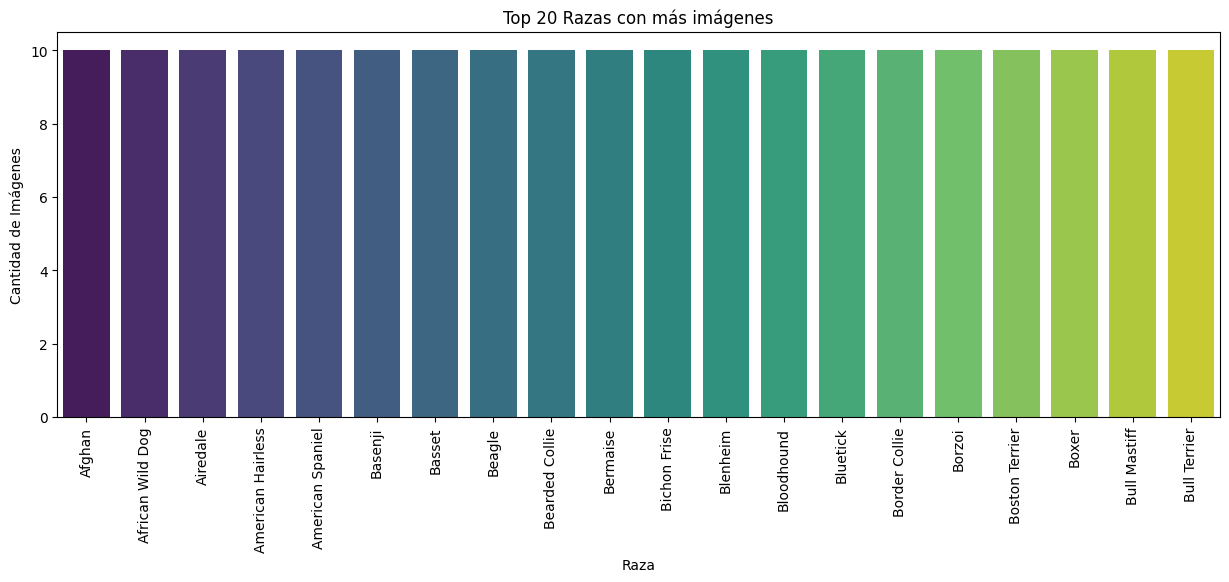

Total de clases: 70
Total de imágenes: 700


In [ ]:
## TO-DO: analisis exploratorio del dataset (distribucion de clases, imagenes por raza, splits).

import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

#dataset_path = Path(settings.dataset_path)
dataset_path = Path("data/dataset/test")

# Contar imágenes por clase
class_counts = {}
for breed_dir in dataset_path.iterdir():
    if breed_dir.is_dir():
        class_counts[breed_dir.name] = len(list(breed_dir.glob('*.jpg')))

# Ordenar para el gráfico
sorted_classes = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 5))
sns.barplot(x=list(sorted_classes.keys())[:20], y=list(sorted_classes.values())[:20], palette="viridis")
plt.xticks(rotation=90)
plt.title("Top 20 Razas con más imágenes")
plt.ylabel("Cantidad de Imágenes")
plt.xlabel("Raza")
plt.show()

print(f"Total de clases: {len(class_counts)}")
print(f"Total de imágenes: {sum(class_counts.values())}")

## 6. Preprocesamiento

TO-DO: definir y justificar resize, normalizacion y data augmentation (horizontal flip,
rotacion, blur, variaciones de brillo y contraste, ruido).

In [6]:
## TO-DO: transformaciones de preprocesamiento y data augmentation (con ejemplos visuales).

from torchvision import transforms

# Transformaciones con Data Augmentation para Entrenamiento
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5), # 50% de probabilidad de voltear
    transforms.RandomRotation(15),          # Rotación leve
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Variación de luz
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones estrictas para Validación/Test
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 7. Modelo A (obligatorio): fine-tuning de ResNet18

`train_classifier` debe guardar el checkpoint en `models/resnet18_finetuned.pth`
(o el nombre configurado en RESNET18_MODEL_NAME). Documentar los hiperparametros
utilizados (learning rate, batch size, epochs, optimizador, scheduler).

In [ ]:
from lib.bootstrap import build_classifier

classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")
classifier.train_classifier()

Iniciando entrenamiento en: cpu
Cargando ResNet18 pre-entrenada para fine-tuning
Epoch 1/3 | Loss: 2.6664 | Accuracy: 0.3095


In [ ]:
metrics_a = classifier.evaluate_classifier()
metrics_a

### Curvas de entrenamiento y matriz de confusion (Modelo A)

TO-DO: graficar las curvas de entrenamiento/validacion y la matriz de confusion.

In [ ]:
## TO-DO: curvas de entrenamiento y matriz de confusion del Modelo A.

history = classifier.history 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Curva de Loss
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Evolución de la Pérdida (Loss)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()

# Curva de Accuracy
ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_title('Evolución de la Precisión (Accuracy)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

cm = metrics_a['confusion_matrix']
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Matriz de Confusión - ResNet18')
plt.show()

## 8. Modelo B (opcional, recomendado): CNN propia

`train_classifier` con el modelo activo `cnn_custom` debe guardar el checkpoint en
`models/cnn_custom.pth` (o el nombre configurado en CNN_CUSTOM_MODEL_NAME).

In [ ]:
# classifier.set_active_model("cnn_custom")
# classifier.train_classifier()
# metrics_b = classifier.evaluate_classifier()
# metrics_b

## 9. Estudio comparativo

TO-DO (pequeño estudio de la Etapa 2):
- Comparar los modelos entrenados: accuracy, precision, recall, specificity, F1.
- Analizar las clases con peor desempeño (falsos positivos / falsos negativos).
- Discutir trade-offs (performance vs costo computacional).
- Copiar las conclusiones al informe (`informe.ipynb`).

In [ ]:
## TO-DO: comparacion entre modelos y analisis de errores.

## 10. Descargar los checkpoints

Descargalos y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Recorda publicarlos en un link de solo lectura publico.

In [ ]:
!ls -lh models/

try:
    from google.colab import files

    files.download(str(settings.model_path / settings.resnet18_model_name))
    # files.download(str(settings.model_path / settings.cnn_custom_model_name))
except ImportError:
    print("Fuera de Colab: los checkpoints quedan en models/")